#### 1. Import des librairies

In [1]:
import pandas as pd
import numpy as np


def _plotly_graph_objects():
    import plotly.graph_objects as go
    return go

#### 2. Import des données

In [2]:
# Calendrier
calendar = pd.read_excel("/Users/arthurlenet/Desktop/structured_products/data/reporting.xlsx", sheet_name="Calendar")

# Données Indice
data = pd.read_excel("/Users/arthurlenet/Desktop/structured_products/data/reporting.xlsx", sheet_name="Reporting")

data

,Date,XS1732593444,Base 100,Daily Return,Cumulative Return,Drawdown,Maximum Drawdown,Volatility,Minimum Spot Level,Maximum Spot Level,...,n of Next Observation Date,Days to Next Observation,Potential Redemption Amount,Potential Coupon Premium,Potential Product Performance,Capital Barrier,Distance to Capital Barrier,Final Protection Amount,Threshold Barrier,Distance to Threshold Barrier
0,2018-07-02,100.000000,100.000000,NaN,0.000000,0.000000,0.000000,NaN,100.000000,100.00000,...,1,365,1070,70,0.070,60,0.666667,60,80,0.250000
1,2018-07-03,97.712839,97.712839,-0.022872,-0.022872,-0.022872,-0.022872,NaN,97.712839,100.00000,...,1,364,1070,70,0.070,60,0.628547,60,80,0.221410
2,2018-07-04,96.430602,96.430602,-0.013122,-0.035694,-0.035694,-0.035694,0.109434,96.430602,100.00000,...,1,363,1070,70,0.070,60,0.607177,60,80,0.205383
3,2018-07-05,94.105209,94.105209,-0.024115,-0.058948,-0.058948,-0.058948,0.095559,94.105209,100.00000,...,1,362,1070,70,0.070,60,0.568420,60,80,0.176315
4,2018-07-06,94.230126,94.230126,0.001327,-0.057699,-0.057699,-0.058948,0.186658,94.105209,100.00000,...,1,361,1070,70,0.070,60,0.570502,60,80,0.177877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2087,2026-08-18,88.625727,88.625727,0.005460,-0.113743,-0.133518,-0.455774,0.189843,54.422615,102.28229,...,16,139,1595,595,0.595,60,0.477095,60,80,0.107822
2088,2026-08-19,87.348993,87.348993,-0.014406,-0.126510,-0.146001,-0.455774,0.189863,54.422615,102.28229,...,16,138,1595,595,0.595,60,0.455817,60,80,0.091862
2089,2026-08-20,87.526000,87.526000,0.002026,-0.124740,-0.144270,-0.455774,0.189819,54.422615,102.28229,...,16,137,1595,595,0.595,60,0.458767,60,80,0.094075
2090,2026-08-21,87.077626,87.077626,-0.005123,-0.129224,-0.148654,-0.455774,0.189782,54.422615,102.28229,...,16,136,1595,595,0.595,60,0.451294,60,80,0.088470


In [3]:
calendar

,n,Evaluation Date,Redemption Date
0,1,2019-07-02,2019-07-16
1,2,2020-01-02,2020-01-16
2,3,2020-07-02,2020-07-16
3,4,2021-01-04,2021-01-18
4,5,2021-07-02,2021-07-16
5,6,2022-01-03,2022-01-17
6,7,2022-07-04,2022-07-18
7,8,2023-01-02,2023-01-16
8,9,2023-07-03,2023-07-17
9,10,2024-01-02,2024-01-16


### Reporting Date

In [4]:
date_reporting = "2026-08-24"

### Graphs

#### 1. Performance base 100 SJ

In [5]:
from __future__ import annotations

import pandas as pd
from pathlib import Path


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "src" / "marketing_production").exists():
            return path
    raise FileNotFoundError("Impossible de trouver la racine du projet structured_products")


PROJECT_ROOT = find_project_root()
ASSET_DIR = PROJECT_ROOT / "src" / "marketing_production" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
UNDERLYING_PERFORMANCE_IMAGE_PATH = ASSET_DIR / "underlying_performance_snapshot.png"


_FRENCH_MONTHS = {
    1: "janv",
    2: "fev",
    3: "mars",
    4: "avr",
    5: "mai",
    6: "juin",
    7: "juil",
    8: "aout",
    9: "sept",
    10: "oct",
    11: "nov",
    12: "dec",
}


def _format_date(date: pd.Timestamp) -> str:
    month = _FRENCH_MONTHS[date.month]
    return f"{month}-{date.strftime('%y')}"


def _tick_dates(
    dates: pd.Series,
    max_ticks: int = 8
) -> list[pd.Timestamp]:

    unique_dates = (
        pd.Series(
            pd.to_datetime(dates)
            .dropna()
            .unique()
        )
        .sort_values()
    )

    if len(unique_dates) <= max_ticks:
        return unique_dates.tolist()

    positions = [
        round(
            i * (len(unique_dates) - 1) / (max_ticks - 1)
        )
        for i in range(max_ticks)
    ]

    return unique_dates.iloc[positions].tolist()


def plot_line_graph(
    dataframe: pd.DataFrame,
    column_date: str,
    column_underlying: str,
    date_reporting,
    *,
    source: str = "",
) -> "go.Figure":

    """
    Graphique de performance en base 100 du sous-jacent
    jusqu'à la date de reporting.
    """

    go = _plotly_graph_objects()

    # --------------------------------------------------
    # Paramètres graphiques fixes
    # --------------------------------------------------

    background_color = "#FFFFFF"
    text_color = "#703205"

    main_color = "#754927"
    secondary_color = "#703205"

    title = "Performance base 100 du sous-jacent"

    legend_name = "Base 100 sous-jacent"

    x_name = "Date"
    y_name = "Base 100"

    # --------------------------------------------------
    # Vérification du DataFrame
    # --------------------------------------------------

    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError(
            "dataframe must be a pandas DataFrame."
        )

    required_columns = [
        column_date,
        column_underlying
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns not found in dataframe: {missing_columns}"
        )

    # --------------------------------------------------
    # Préparation des données
    # --------------------------------------------------

    chart_data = dataframe[
        required_columns
    ].copy()

    chart_data[column_date] = pd.to_datetime(
        chart_data[column_date],
        errors="coerce"
    )

    date_reporting = pd.to_datetime(
        date_reporting,
        errors="coerce"
    )

    if pd.isna(date_reporting):
        raise ValueError(
            "date_reporting must be a valid date."
        )

    chart_data = (
        chart_data
        .dropna(subset=[column_date])
        .sort_values(column_date)
        .reset_index(drop=True)
    )

    # --------------------------------------------------
    # Filtre jusqu'à la date de reporting
    # --------------------------------------------------

    chart_data = chart_data[
        chart_data[column_date] <= date_reporting
    ].copy()

    if chart_data.empty:
        raise ValueError(
            "No data available before or on date_reporting."
        )

    # --------------------------------------------------
    # Création du graphique
    # --------------------------------------------------

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=chart_data[column_date],
            y=chart_data[column_underlying],

            mode="lines",

            name=legend_name,

            line=dict(
                color=main_color,
                width=2.8
            ),

            hovertemplate=(
                f"<b>{legend_name}</b>"
                "<br>"
                "%{x|%Y-%m-%d}"
                "<br>"
                "%{y:.2f}"
                "<extra></extra>"
            ),
        )
    )

    # --------------------------------------------------
    # Dates affichées sur l'axe X
    # --------------------------------------------------

    tick_dates = _tick_dates(
        chart_data[column_date]
    )

    tick_values = [
        pd.Timestamp(date).to_pydatetime()
        for date in tick_dates
    ]

    tick_text = [
        f"<b>{_format_date(pd.Timestamp(date))}</b>"
        for date in tick_dates
    ]

    # --------------------------------------------------
    # Source
    # --------------------------------------------------

    source_date = date_reporting.strftime("%Y-%m-%d")

    if source:
        source_text = (
            f"Source : {source} - {source_date}"
        )
    else:
        source_text = (
            f"Source : {source_date}"
        )

    # --------------------------------------------------
    # Layout
    # --------------------------------------------------

    fig.update_layout(

        title=dict(
            text=f"<b>{title}</b>",
            x=0.5,
            xanchor="center",
            font=dict(
                color=secondary_color,
                size=22
            )
        ),

        plot_bgcolor=background_color,
        paper_bgcolor=background_color,

        font=dict(
            color=text_color,
            family="Arial",
            size=12
        ),

        width=1400,
        height=800,

        margin=dict(
            l=80,
            r=50,
            t=90,
            b=170
        ),

        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.22,
            xanchor="center",
            x=0.5,
            font=dict(
                color=secondary_color,
                size=12
            ),
        ),

        hovermode="x unified",

        annotations=[
            dict(
                text=source_text,
                x=0,
                y=-0.12,
                xref="paper",
                yref="paper",
                showarrow=False,
                xanchor="left",
                yanchor="top",
                font=dict(
                    color=secondary_color,
                    size=13
                ),
            )
        ],
    )

    # --------------------------------------------------
    # Axe X
    # --------------------------------------------------

    fig.update_xaxes(

        title_text=f"<b>{x_name}</b>",

        tickmode="array",

        tickvals=tick_values,

        ticktext=tick_text,

        range=[
            chart_data[column_date].min().to_pydatetime(),
            date_reporting.to_pydatetime()
        ],

        showgrid=True,

        gridcolor="rgba(117, 73, 39, 0.15)",

        zeroline=False,

        linecolor=secondary_color,

        tickfont=dict(
            color=secondary_color,
            size=11,
            family="Arial Bold"
        ),

        title_font=dict(
            color=secondary_color,
            size=13,
            family="Arial Bold"
        ),
    )

    # --------------------------------------------------
    # Axe Y
    # --------------------------------------------------

    fig.update_yaxes(

        title_text=f"<b>{y_name}</b>",

        showgrid=True,

        gridcolor="rgba(117, 73, 39, 0.15)",

        zeroline=False,

        linecolor=secondary_color,

        tickfont=dict(
            color=secondary_color,
            size=11,
            family="Arial Bold"
        ),

        title_font=dict(
            color=secondary_color,
            size=13,
            family="Arial Bold"
        ),
    )

    return fig


fig = plot_line_graph(
    dataframe=data,
    column_date="Date",
    column_underlying="Base 100",
    date_reporting=date_reporting,
    source="Merañ Structured Partners"
)

# --------------------------------------------------
# Export pour la présentation HTML
# --------------------------------------------------

fig.write_image(
    UNDERLYING_PERFORMANCE_IMAGE_PATH,
    scale=2
)

fig.show()

#### 2. Drawdowns SJ

In [6]:
from pathlib import Path


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "src" / "marketing_production").exists():
            return path
    raise FileNotFoundError("Impossible de trouver la racine du projet structured_products")


PROJECT_ROOT = find_project_root()
ASSET_DIR = PROJECT_ROOT / "src" / "marketing_production" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
DRAWDOWN_IMAGE_PATH = ASSET_DIR / "drawdown_snapshot.png"


_FRENCH_MONTHS = {
    1: "janv",
    2: "fev",
    3: "mars",
    4: "avr",
    5: "mai",
    6: "juin",
    7: "juil",
    8: "aout",
    9: "sept",
    10: "oct",
    11: "nov",
    12: "dec",
}


def _format_date_drawdown(date: pd.Timestamp) -> str:
    month = _FRENCH_MONTHS[date.month]
    return f"{month}-{date.strftime('%y')}"


def plot_drawdown_graph(
    dataframe: pd.DataFrame,
    column_date: str,
    column_underlying: str,
    date_reporting,
    *,
    source: str = "",
) -> "go.Figure":

    """
    Graphique du drawdown historique du sous-jacent
    jusqu'à la date de reporting.
    """

    go = _plotly_graph_objects()

    # --------------------------------------------------
    # Paramètres graphiques fixes
    # --------------------------------------------------

    background_color = "#FFFFFF"

    main_color = "#754927"
    secondary_color = "#703205"

    title = "Drawdown du sous-jacent"

    legend_name = "Drawdown sous-jacent"

    x_name = "Date"
    y_name = "Drawdown (%)"

    # --------------------------------------------------
    # Vérification du DataFrame
    # --------------------------------------------------

    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError(
            "dataframe must be a pandas DataFrame."
        )

    required_columns = [
        column_date,
        column_underlying
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns not found in dataframe: {missing_columns}"
        )

    # --------------------------------------------------
    # Préparation des données
    # --------------------------------------------------

    chart_data = dataframe[
        required_columns
    ].copy()

    chart_data[column_date] = pd.to_datetime(
        chart_data[column_date],
        errors="coerce"
    )

    date_reporting = pd.to_datetime(
        date_reporting,
        errors="coerce"
    )

    if pd.isna(date_reporting):
        raise ValueError(
            "date_reporting must be a valid date."
        )

    chart_data = (
        chart_data
        .dropna(subset=[column_date])
        .sort_values(column_date)
        .reset_index(drop=True)
    )

    # --------------------------------------------------
    # Filtre jusqu'à la date de reporting
    # --------------------------------------------------

    chart_data = chart_data[
        chart_data[column_date] <= date_reporting
    ].copy()

    if chart_data.empty:
        raise ValueError(
            "No data available before or on date_reporting."
        )

    # --------------------------------------------------
    # Conversion de la série en numérique
    # --------------------------------------------------

    values = pd.to_numeric(
        chart_data[column_underlying],
        errors="coerce"
    )

    if values.dropna().empty:
        raise ValueError(
            f"Column {column_underlying!r} "
            "must contain valid numeric values."
        )

    # --------------------------------------------------
    # Calcul du drawdown
    # --------------------------------------------------

    running_max = values.cummax()

    drawdown = (
        values
        .div(
            running_max.where(
                running_max.ne(0)
            )
        )
        .sub(1.0)
        * 100
    )

    # --------------------------------------------------
    # Création du graphique
    # --------------------------------------------------

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=chart_data[column_date],
            y=drawdown,

            mode="lines",

            name=legend_name,

            line=dict(
                color=main_color,
                width=1.8
            ),

            fill="tozeroy",
            fillcolor=main_color,
            opacity=0.35,

            hovertemplate=(
                f"<b>{legend_name}</b>"
                "<br>"
                "%{x|%Y-%m-%d}"
                "<br>"
                "%{y:.2f}%"
                "<extra></extra>"
            ),
        )
    )

    # --------------------------------------------------
    # Dates affichées sur l'axe X
    # --------------------------------------------------

    tick_dates = _tick_dates(
        chart_data[column_date]
    )

    tick_values = [
        pd.Timestamp(date).to_pydatetime()
        for date in tick_dates
    ]

    tick_text = [
        f"<b>{_format_date_drawdown(pd.Timestamp(date))}</b>"
        for date in tick_dates
    ]

    # --------------------------------------------------
    # Source
    # --------------------------------------------------

    source_date = date_reporting.strftime("%Y-%m-%d")

    if source:
        source_text = (
            f"Source : {source} - {source_date}"
        )
    else:
        source_text = (
            f"Source : {source_date}"
        )

    # --------------------------------------------------
    # Layout général
    # --------------------------------------------------

    fig.update_layout(

        title=dict(
            text=f"<b>{title}</b>",
            x=0.5,
            xanchor="center",
            font=dict(
                color=secondary_color,
                size=22
            )
        ),

        plot_bgcolor=background_color,
        paper_bgcolor=background_color,

        font=dict(
            color=secondary_color,
            family="Arial",
            size=12
        ),

        width=1400,
        height=500,

        margin=dict(
            l=80,
            r=50,
            t=90,
            b=170
        ),

        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.22,
            xanchor="center",
            x=0.5,
            font=dict(
                color=secondary_color,
                size=12
            ),
        ),

        hovermode="x unified",

        annotations=[
            dict(
                text=source_text,
                x=0,
                y=-0.12,
                xref="paper",
                yref="paper",
                showarrow=False,
                xanchor="left",
                yanchor="top",
                font=dict(
                    color=secondary_color,
                    size=13
                ),
            )
        ],
    )

    # --------------------------------------------------
    # Axe X
    # --------------------------------------------------

    fig.update_xaxes(

        title_text=f"<b>{x_name}</b>",

        tickmode="array",

        tickvals=tick_values,

        ticktext=tick_text,

        range=[
            chart_data[column_date].min().to_pydatetime(),
            date_reporting.to_pydatetime()
        ],

        showgrid=True,

        gridcolor="rgba(117, 73, 39, 0.15)",

        zeroline=False,

        linecolor=secondary_color,

        tickfont=dict(
            color=secondary_color,
            size=11,
            family="Arial Bold"
        ),

        title_font=dict(
            color=secondary_color,
            size=13,
            family="Arial Bold"
        ),
    )

    # --------------------------------------------------
    # Axe Y
    # --------------------------------------------------

    fig.update_yaxes(

        title_text=f"<b>{y_name}</b>",

        ticksuffix="%",

        showgrid=True,

        gridcolor="rgba(117, 73, 39, 0.15)",

        zeroline=True,

        zerolinecolor=secondary_color,

        zerolinewidth=1,

        linecolor=secondary_color,

        tickfont=dict(
            color=secondary_color,
            size=11,
            family="Arial Bold"
        ),

        title_font=dict(
            color=secondary_color,
            size=13,
            family="Arial Bold"
        ),
    )

    return fig


fig = plot_drawdown_graph(
    dataframe=data,
    column_date="Date",
    column_underlying="Base 100",
    date_reporting=date_reporting,
    source="Merañ Structured Partners"
)

# --------------------------------------------------
# Export pour la présentation HTML
# --------------------------------------------------

fig.write_image(
    DRAWDOWN_IMAGE_PATH,
    scale=2
)

fig.show()

Python(9978) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


#### Tables

#### 1. Sous-Jacent Snapshot

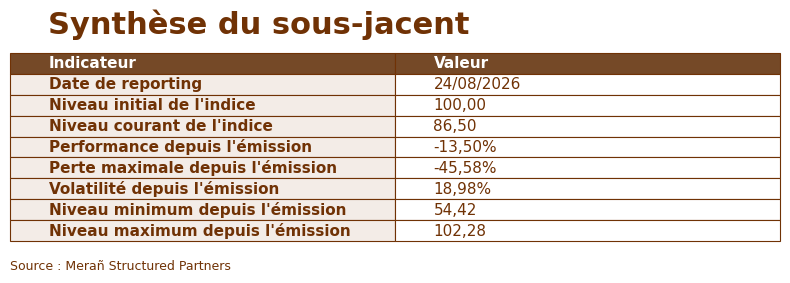

In [7]:
from pathlib import Path


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "src" / "marketing_production").exists():
            return path
    raise FileNotFoundError("Impossible de trouver la racine du projet structured_products")


PROJECT_ROOT = find_project_root()
ASSET_DIR = PROJECT_ROOT / "src" / "marketing_production" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
UNDERLYING_SNAPSHOT_IMAGE_PATH = ASSET_DIR / "underlying_snapshot.png"


# Métrics de reporting
date_reporting = pd.Timestamp("2026-08-24")
initial_index = data['XS1732593444'].iloc[0]
current_index = data.loc[data["Date"] == date_reporting, "XS1732593444"].iloc[0]
performance_itd = data.loc[data["Date"] == date_reporting, "Cumulative Return"].iloc[0] * 100
max_dd_itd = data.loc[data["Date"] == date_reporting, "Maximum Drawdown"].iloc[0] * 100
volatilty_itd = data.loc[data["Date"] == date_reporting, "Volatility"].iloc[0] * 100
min_level_index = data.loc[data["Date"] == date_reporting, "Minimum Spot Level"].iloc[0]
max_level_index = data.loc[data["Date"] == date_reporting, "Maximum Spot Level"].iloc[0]


# Création de la Table
product_snapshot = pd.DataFrame({
    "Indicateur": [
        "Date de reporting",
        "Niveau initial de l'indice",
        "Niveau courant de l'indice",
        "Performance depuis l'émission",
        "Perte maximale depuis l'émission",
        "Volatilité depuis l'émission",
        "Niveau minimum depuis l'émission",
        "Niveau maximum depuis l'émission"
    ],
    "Valeur": [
        date_reporting.strftime("%d/%m/%Y"),
        f"{initial_index:.2f}".replace(".", ","),
        f"{current_index:.2f}".replace(".", ","),
        f"{performance_itd:.2f}%".replace(".", ","),
        f"{max_dd_itd:.2f}%".replace(".", ","),
        f"{volatilty_itd:.2f}%".replace(".", ","),
        f"{min_level_index:.2f}".replace(".", ","),
        f"{max_level_index:.2f}".replace(".", ",")
    ]
})


# Création d'une figure
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2.8))

# Masquer les axes
ax.axis("off")

# Création du tableau
table = ax.table(
    cellText=product_snapshot.values,
    colLabels=product_snapshot.columns,
    cellLoc="left",
    colLoc="left",
    loc="center"
)

# Taille du texte
table.auto_set_font_size(False)
table.set_fontsize(11)

# Hauteur des lignes
table.scale(1, 1.6)

# Couleurs
main_color = "#754927"
secondary_color = "#703205"

# Mise en forme des cellules
for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_facecolor(main_color)
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    elif col == 0:
        cell.set_facecolor("#F3ECE7")
        cell.set_text_props(
            color=secondary_color,
            weight="bold"
        )

    else:
        cell.set_facecolor("white")
        cell.set_text_props(
            color=secondary_color
        )

    cell.set_edgecolor(secondary_color)
    cell.set_linewidth(0.8)

# Ajustement -- espace du haut limité pour le titre, comme
# l'espace du bas est limité pour la source
plt.tight_layout(rect=[0, 0.08, 1, 0.88])

# Position horizontale du titre -- alignée avec le début du
# texte de l'en-tête de la première colonne ("Indicateur")
_axes_position = ax.get_position()
_header_cell = table[(0, 0)]
_title_text_left_axes_frac = _header_cell.get_x() + _header_cell.get_width() * _header_cell.PAD
_title_x = _axes_position.x0 + _title_text_left_axes_frac * (_axes_position.x1 - _axes_position.x0)

# Position horizontale de la source -- alignée avec le trait
# du début de la première colonne (bord gauche du tableau)
_source_x = _axes_position.x0

# Titre -- même taille de police que le titre du graphique
# "Drawdown du sous-jacent" (22), espace limité comme pour la source
fig.text(
    _title_x,
    0.97,
    "Synthèse du sous-jacent",
    ha="left",
    va="top",
    fontsize=22,
    fontweight="bold",
    color=secondary_color
)

# Source en bas, alignée avec le trait de la première colonne
fig.text(
    _source_x,
    0.03,
    "Source : Merañ Structured Partners",
    ha="left",
    va="bottom",
    fontsize=9,
    color=secondary_color
)

# --------------------------------------------------
# Export pour la présentation HTML
# --------------------------------------------------

fig.savefig(
    UNDERLYING_SNAPSHOT_IMAGE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
    edgecolor="none"
)

plt.show()

#### 2. Autocall Snapshot

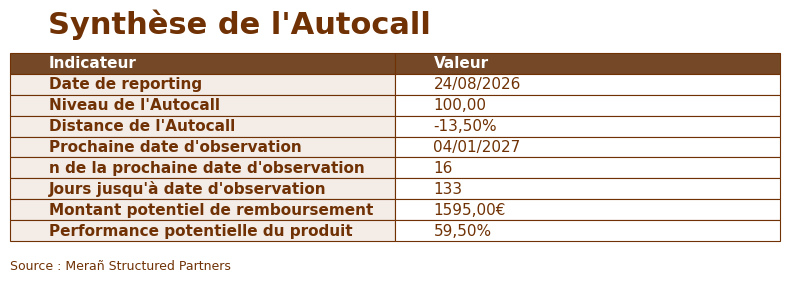

In [8]:
from pathlib import Path


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "src" / "marketing_production").exists():
            return path
    raise FileNotFoundError("Impossible de trouver la racine du projet structured_products")


PROJECT_ROOT = find_project_root()
ASSET_DIR = PROJECT_ROOT / "src" / "marketing_production" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
AUTOCALL_SNAPSHOT_IMAGE_PATH = ASSET_DIR / "autocall_snapshot.png"


# Métrics de reporting
date_reporting = pd.Timestamp("2026-08-24")
autocall_level = data.loc[data["Date"] == date_reporting, "Autocall Level"].iloc[0]
distance_to_autocall = data.loc[data["Date"] == date_reporting, "Distance to Autocall"].iloc[0] * 100
next_observation_date = data.loc[data["Date"] == date_reporting, "Next Observation Date"].iloc[0]
n_next_observation_date = data.loc[data["Date"] == date_reporting, "n of Next Observation Date"].iloc[0]
days_to_next_observation = data.loc[data["Date"] == date_reporting, "Days to Next Observation"].iloc[0]
potential_redemption_amount = data.loc[data["Date"] == date_reporting, "Potential Redemption Amount"].iloc[0]
potential_product_performance = data.loc[data["Date"] == date_reporting, "Potential Product Performance"].iloc[0] * 100

# Création de la Table
autocall_snapshot = pd.DataFrame({
    "Indicateur": [
        "Date de reporting",
        "Niveau de l'Autocall",
        "Distance de l'Autocall",
        "Prochaine date d'observation",
        "n de la prochaine date d'observation",
        "Jours jusqu'à date d'observation",
        "Montant potentiel de remboursement",
        "Performance potentielle du produit"
    ],
    "Valeur": [
        date_reporting.strftime("%d/%m/%Y"),
        f"{autocall_level:.2f}".replace(".", ","),
        f"{distance_to_autocall:.2f}%".replace(".", ","),
        next_observation_date.strftime("%d/%m/%Y"),
        f"{n_next_observation_date:.0f}".replace(".", ","),
        f"{days_to_next_observation:.0f}".replace(".", ","),
        f"{potential_redemption_amount:.2f}€".replace(".", ","),
        f"{potential_product_performance:.2f}%".replace(".", ",")
    ]
})


# Création d'une figure
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2.8))

# Masquer les axes
ax.axis("off")

# Création du tableau
table = ax.table(
    cellText=autocall_snapshot.values,
    colLabels=autocall_snapshot.columns,
    cellLoc="left",
    colLoc="left",
    loc="center"
)

# Taille du texte
table.auto_set_font_size(False)
table.set_fontsize(11)

# Hauteur des lignes
table.scale(1, 1.6)

# Couleurs
main_color = "#754927"
secondary_color = "#703205"

# Mise en forme des cellules
for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_facecolor(main_color)
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    elif col == 0:
        cell.set_facecolor("#F3ECE7")
        cell.set_text_props(
            color=secondary_color,
            weight="bold"
        )

    else:
        cell.set_facecolor("white")
        cell.set_text_props(
            color=secondary_color
        )

    cell.set_edgecolor(secondary_color)
    cell.set_linewidth(0.8)

# Ajustement -- espace du haut limité pour le titre, comme
# l'espace du bas est limité pour la source
plt.tight_layout(rect=[0, 0.08, 1, 0.88])

# Position horizontale du titre -- alignée avec le début du
# texte de l'en-tête de la première colonne ("Indicateur")
_axes_position = ax.get_position()
_header_cell = table[(0, 0)]
_title_text_left_axes_frac = _header_cell.get_x() + _header_cell.get_width() * _header_cell.PAD
_title_x = _axes_position.x0 + _title_text_left_axes_frac * (_axes_position.x1 - _axes_position.x0)

# Position horizontale de la source -- alignée avec le trait
# du début de la première colonne (bord gauche du tableau)
_source_x = _axes_position.x0

# Titre -- même taille de police que le titre du graphique
# "Drawdown du sous-jacent" (22), espace limité comme pour la source
fig.text(
    _title_x,
    0.97,
    "Synthèse de l'Autocall",
    ha="left",
    va="top",
    fontsize=22,
    fontweight="bold",
    color=secondary_color
)

# Source en bas, alignée avec le trait de la première colonne
fig.text(
    _source_x,
    0.03,
    "Source : Merañ Structured Partners",
    ha="left",
    va="bottom",
    fontsize=9,
    color=secondary_color
)

# --------------------------------------------------
# Export pour la présentation HTML
# --------------------------------------------------

fig.savefig(
    AUTOCALL_SNAPSHOT_IMAGE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
    edgecolor="none"
)

plt.show()

#### 3. Capital Barrier Snapshot

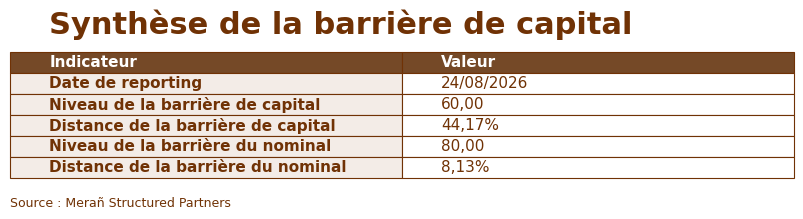

In [9]:
from pathlib import Path


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "src" / "marketing_production").exists():
            return path
    raise FileNotFoundError("Impossible de trouver la racine du projet structured_products")


PROJECT_ROOT = find_project_root()
ASSET_DIR = PROJECT_ROOT / "src" / "marketing_production" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
CAPITAL_BARRIER_SNAPSHOT_IMAGE_PATH = ASSET_DIR / "capital_barrier_snapshot.png"


# Métrics de reporting
date_reporting = pd.Timestamp("2026-08-24")
capital_barrier_level = data.loc[data["Date"] == date_reporting, "Capital Barrier"].iloc[0]
distance_to_capital_barrier = data.loc[data["Date"] == date_reporting, "Distance to Capital Barrier"].iloc[0] * 100
threshold_barrier = data.loc[data["Date"] == date_reporting, "Threshold Barrier"].iloc[0]
distance_to_threshold_barrier = data.loc[data["Date"] == date_reporting, "Distance to Threshold Barrier"].iloc[0] * 100

# Création de la Table
capital_barrier_snapshot = pd.DataFrame({
    "Indicateur": [
        "Date de reporting",
        "Niveau de la barrière de capital",
        "Distance de la barrière de capital",
        "Niveau de la barrière du nominal",
        "Distance de la barrière du nominal",
    ],
    "Valeur": [
        date_reporting.strftime("%d/%m/%Y"),
        f"{capital_barrier_level:.2f}".replace(".", ","),
        f"{distance_to_capital_barrier:.2f}%".replace(".", ","),
        f"{threshold_barrier:.2f}".replace(".", ","),
        f"{distance_to_threshold_barrier:.2f}%".replace(".", ",")
    ]
})


# Création d'une figure -- hauteur réduite par rapport aux
# tableaux "Synthèse du sous-jacent"/"Synthèse de l'Autocall"
# (8 lignes) puisque cette table n'a que 5 lignes ; cela évite
# l'espace vide excédentaire entre le tableau et la source.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2.123))

# Masquer les axes
ax.axis("off")

# Création du tableau
table = ax.table(
    cellText=capital_barrier_snapshot.values,
    colLabels=capital_barrier_snapshot.columns,
    cellLoc="left",
    colLoc="left",
    loc="center"
)

# Taille du texte
table.auto_set_font_size(False)
table.set_fontsize(11)

# Couleurs
main_color = "#754927"
secondary_color = "#703205"

# Hauteur des lignes -- hauteur absolue fixée explicitement
# (au lieu de table.scale(), qui redistribue proportionnellement
# au nombre de lignes) pour obtenir la même épaisseur d'en-tête
# que dans "Synthèse de l'Autocall", quel que soit le nombre de
# lignes de cette table.
for (row, col), cell in table.get_celld().items():
    cell.set_height(0.1649)

# Mise en forme des cellules
for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_facecolor(main_color)
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    elif col == 0:
        cell.set_facecolor("#F3ECE7")
        cell.set_text_props(
            color=secondary_color,
            weight="bold"
        )

    else:
        cell.set_facecolor("white")
        cell.set_text_props(
            color=secondary_color
        )

    cell.set_edgecolor(secondary_color)
    cell.set_linewidth(0.8)

# Ajustement -- marges calibrées empiriquement (en remplacement
# de tight_layout, dont le résultat n'est pas prévisible en
# combinaison avec des hauteurs de cellule explicites) pour
# obtenir le même espace visuel titre/tableau et tableau/source
# que "Synthèse de l'Autocall" et "Synthèse du sous-jacent".
plt.subplots_adjust(left=0.01, right=0.99, top=0.7743, bottom=0.1743)

# Position horizontale du titre -- alignée avec le début du
# texte de l'en-tête de la première colonne ("Indicateur")
_axes_position = ax.get_position()
_header_cell = table[(0, 0)]
_title_text_left_axes_frac = _header_cell.get_x() + _header_cell.get_width() * _header_cell.PAD
_title_x = _axes_position.x0 + _title_text_left_axes_frac * (_axes_position.x1 - _axes_position.x0)

# Position horizontale de la source -- alignée avec le trait
# du début de la première colonne (bord gauche du tableau)
_source_x = _axes_position.x0

# Titre -- même taille de police que le titre du graphique
# "Drawdown du sous-jacent" (22)
fig.text(
    _title_x,
    0.97,
    "Synthèse de la barrière de capital",
    ha="left",
    va="top",
    fontsize=22,
    fontweight="bold",
    color=secondary_color
)

# Source en bas, alignée avec le trait de la première colonne
fig.text(
    _source_x,
    0.03,
    "Source : Merañ Structured Partners",
    ha="left",
    va="bottom",
    fontsize=9,
    color=secondary_color
)

# --------------------------------------------------
# Export pour la présentation HTML
# --------------------------------------------------

fig.savefig(
    CAPITAL_BARRIER_SNAPSHOT_IMAGE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
    edgecolor="none"
)

plt.show()

### Autocall Monitoring

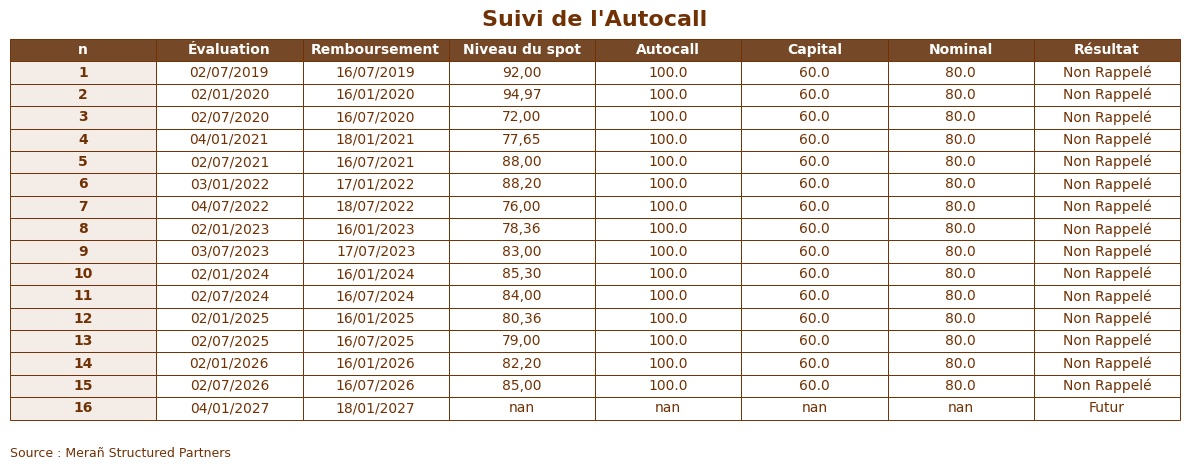

In [10]:
from pathlib import Path


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "src" / "marketing_production").exists():
            return path
    raise FileNotFoundError("Impossible de trouver la racine du projet structured_products")


PROJECT_ROOT = find_project_root()
ASSET_DIR = PROJECT_ROOT / "src" / "marketing_production" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
AUTOCALL_MONITORING_IMAGE_PATH = ASSET_DIR / "autocall_monitoring_snapshot.png"


autocall_monitoring = calendar.copy()

# Recherche de la première Evaluation Date >= date_reporting
next_evaluation_date = autocall_monitoring.loc[
    autocall_monitoring["Evaluation Date"] >= date_reporting,
    "Evaluation Date"
].min()

# Suppression de toutes les lignes après cette date
autocall_monitoring = autocall_monitoring[autocall_monitoring["Evaluation Date"] <= next_evaluation_date].copy()

# Refaire l'index
autocall_monitoring = autocall_monitoring.reset_index(drop=True)

# Récupération du niveau de Spot correspondant à chaque Evaluation Date
autocall_monitoring = autocall_monitoring.merge(
    data[["Date", "XS1732593444", "Autocall Level", "Capital Barrier", "Threshold Barrier"]],
    left_on="Evaluation Date",
    right_on="Date",
    how="left"
)

# Renommer la colonne pour le spot et supprimer la colonne date merge
autocall_monitoring = autocall_monitoring.rename(columns={"XS1732593444": "Spot Level"}).drop(columns=["Date"])

# Créaation de la colonne Result
def determine_result(row):
    if row["Spot Level"] >= row["Autocall Level"]:
        return "Rappel"
    elif row["Spot Level"] < row["Autocall Level"]:
        return "Non Rappelé"
    else:
        return "Futur"


autocall_monitoring["Result"] = autocall_monitoring.apply(determine_result, axis=1)



# Bon format colonne date
autocall_monitoring["Evaluation Date"] = (pd.to_datetime(autocall_monitoring["Evaluation Date"]).dt.strftime("%d/%m/%Y"))
autocall_monitoring["Redemption Date"] = (pd.to_datetime(autocall_monitoring["Redemption Date"]).dt.strftime("%d/%m/%Y"))

# Bon format colonne Index
autocall_monitoring["Spot Level"] = autocall_monitoring["Spot Level"].apply(lambda x: f"{x:.2f}".replace(".", ","))

# Renommer les colonnes 
autocall_monitoring = autocall_monitoring.rename(columns={"Evaluation Date" : "Évaluation"})
autocall_monitoring = autocall_monitoring.rename(columns={"Redemption Date" : "Remboursement"})
autocall_monitoring = autocall_monitoring.rename(columns={"Spot Level" : "Niveau du spot"})
autocall_monitoring = autocall_monitoring.rename(columns={"Autocall Level" : "Autocall"})
autocall_monitoring = autocall_monitoring.rename(columns={"Capital Barrier" : "Capital"}) 
autocall_monitoring = autocall_monitoring.rename(columns={"Threshold Barrier" : "Nominal"}) 
autocall_monitoring = autocall_monitoring.rename(columns={"Result" : "Résultat"}) 


# Création du tableau final
#--------------------------------------------------
# Création de la figure
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

# Masquer les axes
ax.axis("off")

# --------------------------------------------------
# Création du tableau
# --------------------------------------------------

table = ax.table(
    cellText=autocall_monitoring.values,
    colLabels=autocall_monitoring.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

# --------------------------------------------------
# Taille et dimensions
# --------------------------------------------------

table.auto_set_font_size(False)
table.set_fontsize(10)

# Hauteur des lignes
table.scale(1, 1.6)

# --------------------------------------------------
# Couleurs
# --------------------------------------------------

main_color = "#754927"
secondary_color = "#703205"
light_color = "#F3ECE7"

# --------------------------------------------------
# Mise en forme des cellules
# --------------------------------------------------

for (row, col), cell in table.get_celld().items():

    # En-tête
    if row == 0:
        cell.set_facecolor(main_color)
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    # Première colonne
    elif col == 0:
        cell.set_facecolor(light_color)
        cell.set_text_props(
            color=secondary_color,
            weight="bold"
        )

    # Autres cellules
    else:
        cell.set_facecolor("white")
        cell.set_text_props(
            color=secondary_color
        )

    # Bordures
    cell.set_edgecolor(secondary_color)
    cell.set_linewidth(0.7)

# --------------------------------------------------
# Mise en forme spécifique de la colonne Result
# --------------------------------------------------

result_col = autocall_monitoring.columns.get_loc("Résultat")

for row in range(1, len(autocall_monitoring) + 1):

    value = autocall_monitoring.iloc[row - 1]["Résultat"]

    cell = table[(row, result_col)]

    if value == "Autocall":
        cell.set_text_props(
            weight="bold",
            color=main_color
        )

    elif value == "Not Autocall":
        cell.set_text_props(
            color=secondary_color
        )

    elif value == "Future":
        cell.set_text_props(
            style="italic",
            color=secondary_color
        )

# --------------------------------------------------
# Titre
# --------------------------------------------------

ax.set_title(
    "Suivi de l'Autocall",
    fontsize=16,
    fontweight="bold",
    color=secondary_color,
    pad=30
)

# --------------------------------------------------
# Ajustement
# --------------------------------------------------

plt.tight_layout(rect=[0, 0.06, 1, 0.95])

# --------------------------------------------------
# Source en bas, alignée avec le trait de la première colonne
# --------------------------------------------------

_axes_position = ax.get_position()
_source_x = _axes_position.x0

fig.text(
    _source_x,
    0.02,
    "Source : Merañ Structured Partners",
    ha="left",
    va="bottom",
    fontsize=9,
    color=secondary_color
)

# --------------------------------------------------
# Export pour la présentation HTML
# --------------------------------------------------

fig.savefig(
    AUTOCALL_MONITORING_IMAGE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
    edgecolor="none"
)

plt.show()